# 1.Exploratory Data Analysis (EDA) – Inventory, Sales & Purchase Data

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.holtwinters import ExponentialSmoothing



In [20]:
!pip install statsmodels




[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


# 2. LOAD DATA

In [21]:
sales = pd.read_csv( "SalesFINAL12312016.csv")
purchases = pd.read_csv( "PurchasesFINAL12312016.csv")
invoice = pd.read_csv("InvoicePurchases12312016.csv")
beg_inv = pd.read_csv("EndInvFINAL12312016.csv")
end_inv = pd.read_csv("BegInvFINAL12312016.csv")
prices = pd.read_csv("2017PurchasePricesDec.csv")


In [3]:
sales.head()

,InventoryId,Store,Brand,Description,Size,SalesQuantity,SalesDollars,SalesPrice,SalesDate,Volume,Classification,ExciseTax,VendorNo,VendorName
0,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,16.49,16.49,1/1/2016,750,1,0.79,12546,JIM BEAM BRANDS COMPANY
1,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,2,32.98,16.49,1/2/2016,750,1,1.57,12546,JIM BEAM BRANDS COMPANY
2,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,16.49,16.49,1/3/2016,750,1,0.79,12546,JIM BEAM BRANDS COMPANY
3,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,14.49,14.49,1/8/2016,750,1,0.79,12546,JIM BEAM BRANDS COMPANY
4,1_HARDERSFIELD_1005,1,1005,Maker's Mark Combo Pack,375mL 2 Pk,2,69.98,34.99,1/9/2016,375,1,0.79,12546,JIM BEAM BRANDS COMPANY


In [4]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 14 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   InventoryId     1048575 non-null  object 
 1   Store           1048575 non-null  int64  
 2   Brand           1048575 non-null  int64  
 3   Description     1048575 non-null  object 
 4   Size            1048575 non-null  object 
 5   SalesQuantity   1048575 non-null  int64  
 6   SalesDollars    1048575 non-null  float64
 7   SalesPrice      1048575 non-null  float64
 8   SalesDate       1048575 non-null  object 
 9   Volume          1048575 non-null  int64  
 10  Classification  1048575 non-null  int64  
 11  ExciseTax       1048575 non-null  float64
 12  VendorNo        1048575 non-null  int64  
 13  VendorName      1048575 non-null  object 
dtypes: float64(3), int64(6), object(5)
memory usage: 112.0+ MB


In [5]:
sales.describe()

,Store,Brand,SalesQuantity,SalesDollars,SalesPrice,Volume,Classification,ExciseTax,VendorNo
count,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06
mean,4.008063e+01,1.216959e+04,2.337619e+00,3.160420e+01,1.543162e+01,9.500280e+02,1.416550e+00,1.326847e+00,6.995043e+03
std,2.435739e+01,1.241921e+04,3.511492e+00,6.570249e+01,1.404967e+01,7.142708e+02,4.929872e-01,3.407898e+00,8.426736e+03
min,1.000000e+00,5.800000e+01,1.000000e+00,4.900000e-01,4.900000e-01,5.000000e+01,1.000000e+00,1.000000e-02,2.000000e+00
25%,1.500000e+01,3.680000e+03,1.000000e+00,1.099000e+01,8.990000e+00,7.500000e+02,1.000000e+00,1.600000e-01,3.252000e+03
50%,3.900000e+01,6.296000e+03,1.000000e+00,1.799000e+01,1.299000e+01,7.500000e+02,1.000000e+00,6.800000e-01,4.425000e+03
75%,6.400000e+01,1.795400e+04,2.000000e+00,3.199000e+01,1.899000e+01,1.500000e+03,2.000000e+00,1.570000e+00,9.552000e+03
max,7.900000e+01,9.008900e+04,4.320000e+02,1.327997e+04,4.999990e+03,2.000000e+04,2.000000e+00,3.785200e+02,1.733570e+05


# 3. BASIC DATA UNDERSTANDING

In [6]:
# Data Shapes
print("Sales:", sales.shape)
print("Purchases:", purchases.shape)
print("Invoice:", invoice.shape)
print("Beginning Inventory:", beg_inv.shape)
print("Ending Inventory:", end_inv.shape)
print("Prices:", prices.shape)


Sales: (1048575, 14)
Purchases: (2372474, 16)
Invoice: (5543, 10)
Beginning Inventory: (224489, 9)
Ending Inventory: (206529, 9)
Prices: (12261, 9)


In [22]:
# Column Information
sales.info()
purchases.info()
invoice.info()

print(sales.columns)
print(purchases.columns)
print(invoice.columns)



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 14 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   InventoryId     1048575 non-null  object 
 1   Store           1048575 non-null  int64  
 2   Brand           1048575 non-null  int64  
 3   Description     1048575 non-null  object 
 4   Size            1048575 non-null  object 
 5   SalesQuantity   1048575 non-null  int64  
 6   SalesDollars    1048575 non-null  float64
 7   SalesPrice      1048575 non-null  float64
 8   SalesDate       1048575 non-null  object 
 9   Volume          1048575 non-null  int64  
 10  Classification  1048575 non-null  int64  
 11  ExciseTax       1048575 non-null  float64
 12  VendorNo        1048575 non-null  int64  
 13  VendorName      1048575 non-null  object 
dtypes: float64(3), int64(6), object(5)
memory usage: 112.0+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2372474 entries, 0 to

# 4. MISSING VALUE ANALYSIS

In [23]:
def missing_values(df, name):
    print(f"\nMissing Values in {name}")
    print(df.isnull().sum().sort_values(ascending=False))

missing_values(sales, "Sales")
missing_values(purchases, "Purchases")
missing_values(invoice, "Invoice")



Missing Values in Sales
InventoryId       0
Store             0
Brand             0
Description       0
Size              0
SalesQuantity     0
SalesDollars      0
SalesPrice        0
SalesDate         0
Volume            0
Classification    0
ExciseTax         0
VendorNo          0
VendorName        0
dtype: int64

Missing Values in Purchases
Size              3
InventoryId       0
Brand             0
Store             0
Description       0
VendorNumber      0
VendorName        0
PONumber          0
PODate            0
ReceivingDate     0
InvoiceDate       0
PayDate           0
PurchasePrice     0
Quantity          0
Dollars           0
Classification    0
dtype: int64

Missing Values in Invoice
Approval        5169
VendorNumber       0
VendorName         0
InvoiceDate        0
PODate             0
PONumber           0
PayDate            0
Quantity           0
Dollars            0
Freight            0
dtype: int64


# 5. DATE CONVERSION

In [24]:
sales['SalesDate'] = pd.to_datetime(sales['SalesDate'])

purchases['PODate'] = pd.to_datetime(purchases['PODate'])
purchases['ReceivingDate'] = pd.to_datetime(purchases['ReceivingDate'])

invoice['InvoiceDate'] = pd.to_datetime(invoice['InvoiceDate'])



# 6. SALES PERFORMANCE ANALYSIS

In [25]:
# Total Sales Value
sales['SalesValue'] = sales['SalesQuantity'] * sales['SalesPrice']
print("Total Sales Value:", sales['SalesValue'].sum())


Total Sales Value: 33139375.289999995


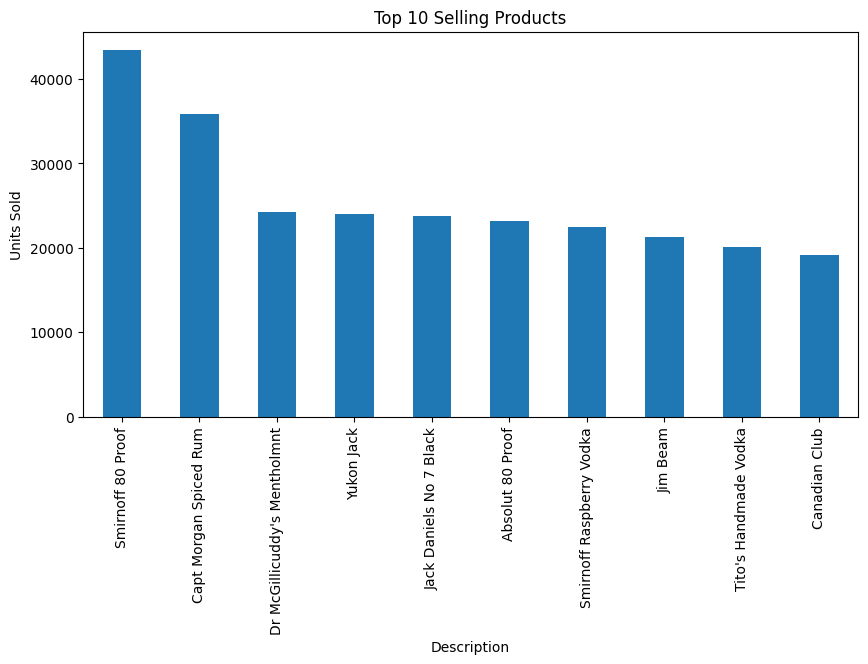

In [26]:
# Top 10 Selling Products
top_products = (
    sales.groupby('Description')['SalesQuantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products.plot(kind='bar', figsize=(10,5), title='Top 10 Selling Products')
plt.ylabel("Units Sold")
plt.show()



#  7. DEMAND FORECASTING

In [28]:
store_sales = sales.groupby('Store')['SalesValue'].sum().sort_values(ascending=False)
print(store_sales)


Store
34    1537806.51
15    1422998.94
76    1402698.59
73    1266850.62
66    1257824.93
         ...    
28      89100.76
37      66599.43
29      46191.93
26      33599.00
3       30556.67
Name: SalesValue, Length: 79, dtype: float64


# 8.  DEMAND FORECASTING (Time Series)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_23952\1229778470.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample('M')['SalesQuantity']


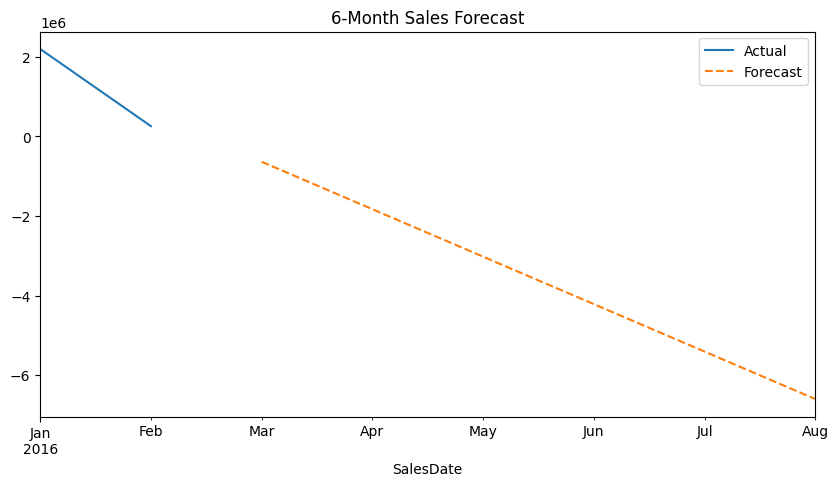

In [29]:
monthly_sales = (
    sales
    .set_index('SalesDate')
    .resample('M')['SalesQuantity']
    .sum()
)

model = ExponentialSmoothing(
    monthly_sales,
    trend='add',
    seasonal=None
)

fit = model.fit()
forecast = fit.forecast(6)

plt.figure(figsize=(10,5))
monthly_sales.plot(label='Actual')
forecast.plot(label='Forecast', linestyle='--')
plt.legend()
plt.title("6-Month Sales Forecast")
plt.show()


# 9. ABC ANALYSIS (Revenue-Based)

In [30]:
sales['Revenue'] = sales['SalesQuantity'] * sales['SalesPrice']

abc = (
    sales.groupby('Description')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

abc['CumulativePercent'] = abc['Revenue'].cumsum() / abc['Revenue'].sum()

def abc_category(x):
    if x <= 0.7:
        return 'A'
    elif x <= 0.9:
        return 'B'
    else:
        return 'C'

abc['ABC_Category'] = abc['CumulativePercent'].apply(abc_category)

abc.head()


,Description,Revenue,CumulativePercent,ABC_Category
0,Capt Morgan Spiced Rum,610008.34,0.018407,A
1,Jack Daniels No 7 Black,558064.03,0.035247,A
2,Absolut 80 Proof,422095.29,0.047984,A
3,Tito's Handmade Vodka,420186.25,0.060664,A
4,Ketel One Vodka,417950.59,0.073276,A


# 8. EOQ (Economic Order Quantity)

In [33]:
annual_demand = sales.groupby('Description')['SalesQuantity'].sum()

ordering_cost = 50     # assumed
holding_cost = 2       # assumed

eoq = np.sqrt((2 * annual_demand * ordering_cost) / holding_cost)

eoq_df = eoq.reset_index()
eoq_df.columns = ['Product', 'EOQ']

eoq_df.head()


,Product,EOQ
0,(RI) 1,44.721360
1,10 Span Cab Svgn CC,34.641016
2,10 Span Chard CC,64.807407
3,10 Span Pnt Nr CC,39.370039
4,12 Days of Pearls Gift Set,36.055513


# 9.  REORDER POINT ANALYSIS

In [34]:
daily_demand = annual_demand / 365
lead_time_days = 7  # average

reorder_point = daily_demand * lead_time_days

rop_df = reorder_point.reset_index()
rop_df.columns = ['Product', 'ReorderPoint']

rop_df.head()




,Product,ReorderPoint
0,(RI) 1,0.767123
1,10 Span Cab Svgn CC,0.460274
2,10 Span Chard CC,1.610959
3,10 Span Pnt Nr CC,0.594521
4,12 Days of Pearls Gift Set,0.498630


# 10. LEAD TIME ANALYSIS

# ⏱ Lead Time = ReceivingDate − PODate


In [35]:
purchases['LeadTimeDays'] = (
    purchases['ReceivingDate'] - purchases['PODate']
).dt.days



#  Supplier Lead Time

supplier_lead_time = (
    purchases.groupby('VendorName')['LeadTimeDays']
    .mean()
    .sort_values()
)

supplier_lead_time.head(10)



# 11. VENDOR COST ANALYSIS

In [38]:
vendor_cost = (
    purchases.groupby('VendorName')['PurchasePrice']
    .mean()
    .sort_values()
)

vendor_cost.head(10)


VendorName
SILVER MOUNTAIN CIDERS         4.540000
LAUREATE IMPORTS CO            4.860000
BRONCO WINE COMPANY            5.227143
FANTASY FINE WINES CORP        5.360000
LATITUDE BEVERAGE COMPANY      5.968420
TREASURY WINE ESTATES          6.098832
TRINCHERO FAMILY ESTATES       6.232757
MILTONS DISTRIBUTING CO        6.814783
CONSTELLATION BRANDS INC       7.096473
WINE GROUP INC                 7.186433
Name: PurchasePrice, dtype: float64

# 12. COST vs LEAD TIME TRADEOFF

In [39]:
vendor_performance = pd.merge(
    supplier_lead_time.reset_index(),
    vendor_cost.reset_index(),
    on='VendorName'
)

vendor_performance.head()


,VendorName,LeadTimeDays,PurchasePrice
0,TRUETT HURST,5.000000,9.860000
1,HIGHLAND WINE MERCHANTS LLC,5.321429,15.225000
2,LOYAL DOG WINERY,5.950000,9.670000
3,MARTIGNETTI COMPANIES,6.697279,14.387993
4,ALISA CARR BEVERAGES,6.809524,98.810317


# 13. INVENTORY TURNOVER RATIO

In [40]:
avg_inventory = (
    beg_inv.groupby('Description')['onHand'].mean() +
    end_inv.groupby('Description')['onHand'].mean()
) / 2

cogs = sales.groupby('Description')['SalesQuantity'].sum()

inventory_turnover = (cogs / avg_inventory).sort_values(ascending=False)

inventory_turnover.head()


Description
Mionetto IL Lambrusco Sprklg           inf
Smirnoff 80 Proof               472.224648
Capt Morgan Spiced Rum          418.395727
Yukon Jack                      405.483911
Dr McGillicuddy's Mentholmnt    386.146111
dtype: float64

# 14. Key Business Insights

- A-category products drive majority of revenue → strict inventory control
- EOQ reduces ordering & holding cost
- Reorder points prevent stockouts
- High-cost + slow vendors should be renegotiated
-Low inventory turnover indicates dead stock

# Solution Assumptions

# 📍 Data Assumptions
- Historical sales patterns are representative of future demand
- No major seasonality shocks beyond observed data
- Missing values are handled via aggregation or exclusion

# 📍 Demand Forecasting Assumptions
- Demand follows historical trends
- Short-term forecasting is sufficient for inventory planning
- External market disruptions are ignored

# 📍 ABC Analysis Assumptions
- Annual sales value = Quantity × Unit Price
- Pareto principle (80/20 rule) applies
- High-value items need tighter control

# 📍 EOQ Assumptions
- Ordering cost is assumed constant per order
- Holding cost is assumed as a fixed cost per unit
- Demand rate is stable over the analysis period

# 📍 Reorder Point Assumptions
- Average daily demand is used for calculations
- Lead time is consistent for each supplier
- Safety stock is not explicitly modeled

# 📍 Lead Time Assumptions
- Lead time is calculated as:
  - Receiving Date − Purchase Order Date
- Supplier performance is consistent over time

# 🏁 Final Business Outputs
- Optimal inventory levels by product category
- List of high-priority (A-category) products
- EOQ values to guide purchase quantity decisions
- Reorder points to avoid stockouts
- Supplier lead-time rankings
- Actionable insights for procurement optimization


# 📌 Final Business Outputs Summary
- Product-level demand forecasts to predict future sales
- ABC classification to prioritize high-value and critical inventory
- Optimal order quantities (EOQ) to minimize ordering and holding costs
- Reorder points to trigger timely replenishment and avoid stockouts
- Supplier lead time analysis to identify efficient and slow vendors
- Inventory turnover metrics to detect slow-moving and excess stock
- Store-level sales insights to support location-wise inventory planning
- Actionable recommendations for procurement and stock control decisions
- Reduced inventory carrying cost and minimized financial loss
- Data-driven decision support replacing spreadsheet-based analysis


# 1️⃣ Demand Forecasting
- Historical sales data is analyzed at the product level to understand demand patterns.
- Time-series models (Exponential Smoothing) are applied to forecast short-term future demand.
- Forecasted demand helps align inventory levels with expected sales.
- Reduces overstocking of slow-moving items and stockouts of fast-moving products.

# 2️⃣ ABC Analysis
- Products are classified based on their contribution to total sales value.
- Category A items represent high-value products requiring strict inventory control.
- Category B items require moderate monitoring and replenishment.
- Category C items are low-priority products with minimal control requirements.
- Enables focused inventory management and better working capital utilization.

# 3️⃣ Economic Order Quantity (EOQ) Analysis
- EOQ is calculated to determine the optimal order quantity for each product.
- Balances ordering costs and inventory holding costs.
- Prevents frequent small orders and excess inventory accumulation.
- Supports cost-efficient procurement and Just-In-Time inventory practices where applicable.

# 4️⃣ Reorder Point Analysis
- Reorder points are calculated using average daily demand and supplier lead time.
- Ensures replenishment orders are placed before inventory reaches critical levels.
- Maintains continuous product availability across locations.
- Reduces emergency purchases and operational disruptions.

# 5️⃣ Lead Time Analysis
- Lead time is derived from purchase order date to invoice date for each supplier.
- Average lead time is calculated to evaluate supplier efficiency.
- Identifies suppliers causing procurement delays.
- Supports process improvement through supplier optimization and reduced waiting periods.